<a href="https://colab.research.google.com/github/ranjiparker/vst-animated/blob/main/frcnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub

# for downloadind and displaying image
import matplotlib.pyplot as plt
import tempfile
from six.moves.urllib.request import urlopen
from six import BytesIO
# for dataframe
import pandas as pd
# for drawing onto the image
import numpy as np
from PIL import Image,ImageColor,ImageDraw,ImageFont,ImageOps

import time


In [ ]:
def disp_ima(image):
  fig = plt.figure(figsize=(18, 13))
  plt.grid(False)
  plt.imshow(image)

def get_and_reshape_img(url, width=250, height=250, display=False):
  ruff, name = tempfile.mkstemp(suffix=".jpg")
  response = urlopen(url)
  image_data = response.read()
  image_data = BytesIO(image_data)
  pil_ima = Image.open(image_data)
  pil_ima = ImageOps.fit(pil_ima, (width, height), Image.ANTIALIAS)
  pil_ima_rgb = pil_ima.convert("RGB")
  pil_ima_rgb.save(name, format="JPEG", quality=90)
  print("Image downloaded to %s." % name)
  if display:
    disp_ima(pil_ima)
  return name

In [ ]:
def boxes_on_image(image,ymin,xmin,ymax,xmax,color,font,thickness=4,display_str_list=()):
  draw = ImageDraw.Draw(image)
  width, height = image.size
  (left, right, top, bottom) = (xmin * width, xmax * width,
                                ymin * height, ymax * height)
  draw.line([(left, top), (left, bottom), (right, bottom), (right, top),
             (left, top)],
            width=thickness,
            fill=color)

  display_heights = [font.getsize(ds)[1] for ds in display_str_list]

  total_height = (1 + 2 * 0.05) * sum(display_heights)

  if top > total_height:
    text_bottom = top
  else:
    text_bottom = top + total_height
  
  for display_str in display_str_list[::-1]:
    text_width, text_height = font.getsize(display_str)
    margin = np.ceil(0.05 * text_height)
    draw.rectangle([(left, text_bottom - text_height - 2 * margin),
                    (left + text_width, text_bottom)],
                   fill=color)
    draw.text((left + margin, text_bottom - text_height - margin),
              display_str,
              fill="black",
              font=font)
    text_bottom -= text_height - 2 * margin

In [ ]:
def drawing_boxes(image, boxes, class_names, scores, max_boxes=10, min_score=0.1):
  
  colors = list(ImageColor.colormap.values())

  try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/liberation/LiberationSansNarrow-Regular.ttf",
                              25)
  except IOError:
    print("Font not found, using default font.")
    font = ImageFont.load_default()

  for i in range(min(boxes.shape[0], max_boxes)):
    if scores[i] >= min_score:
      ymin, xmin, ymax, xmax = tuple(boxes[i])
      display_str = "{}: {}%".format(class_names[i].decode("ascii"),
                                     int(100 * scores[i]))
      color = colors[hash(class_names[i]) % len(colors)]
      image_pil = Image.fromarray(np.uint8(image)).convert("RGB")
      boxes_on_image(image_pil,ymin,xmin,ymax,xmax,color,font,display_str_list=[display_str])
      np.copyto(image, np.array(image_pil))
  return image

In [ ]:
module = "https://tfhub.dev/google/faster_rcnn/openimages_v4/inception_resnet_v2/1" #@param ["https://tfhub.dev/google/openimages_v4/ssd/mobilenet_v2/1", "https://tfhub.dev/google/faster_rcnn/openimages_v4/inception_resnet_v2/1"]

model = hub.load(module).signatures['default']

INFO:tensorflow:Saver not created because there are no variables in the graph to restore


INFO:tensorflow:Saver not created because there are no variables in the graph to restore


In [ ]:
def load_image(path):
  imgage_path = tf.io.read_file(path)
  imgage_path = tf.image.decode_jpeg(imgage_path, channels=3)
  return imgage_path

In [ ]:
def run_model(model, path):
  img = load_image(path)
  summary=[]

  converted_img  = tf.image.convert_image_dtype(img, tf.float32)[tf.newaxis, ...]
  start = time.time()
  result = model(converted_img)
  end = time.time()

  result = {key:value.numpy() for key,value in result.items()}

  print("Found %d objects." % len(result["detection_scores"]))
  print("Inference time: ", end-start)
  image_with_boxes = drawing_boxes(
      img.numpy(), result["detection_boxes"],
      result["detection_class_entities"], result["detection_scores"])
  
  
  d={}
  for i in range(len(result["detection_class_entities"])):
    try:
      d[result["detection_class_entities"][i].decode("utf-8")].append(result["detection_scores"][i])

    except:
      d[result["detection_class_entities"][i].decode("utf-8")]=[result["detection_scores"][i]]
  # print(d)

  for i in d:
    # s=0
    # n=0
    # for value in d[i]:
    #   s+=value
    #   n+=1
    
    d[i]=max(d[i])
  print(d)
  avg=0
  for i in d:
    avg+=d[i]
  print("Average prediction accuracy for "+ str(len(d))+" class is:"+str(avg/len(d)))


  # summary.append(list(result["detection_class_entities"]))
  # for i in range(len(summary)):
  #   summary[i]+="-"+str(result["detection_scores"][i])



  print('\n'.join(map(str, summary)))
  disp_ima(image_with_boxes)

Image downloaded to /tmp/tmp77l6bvmy.jpg.


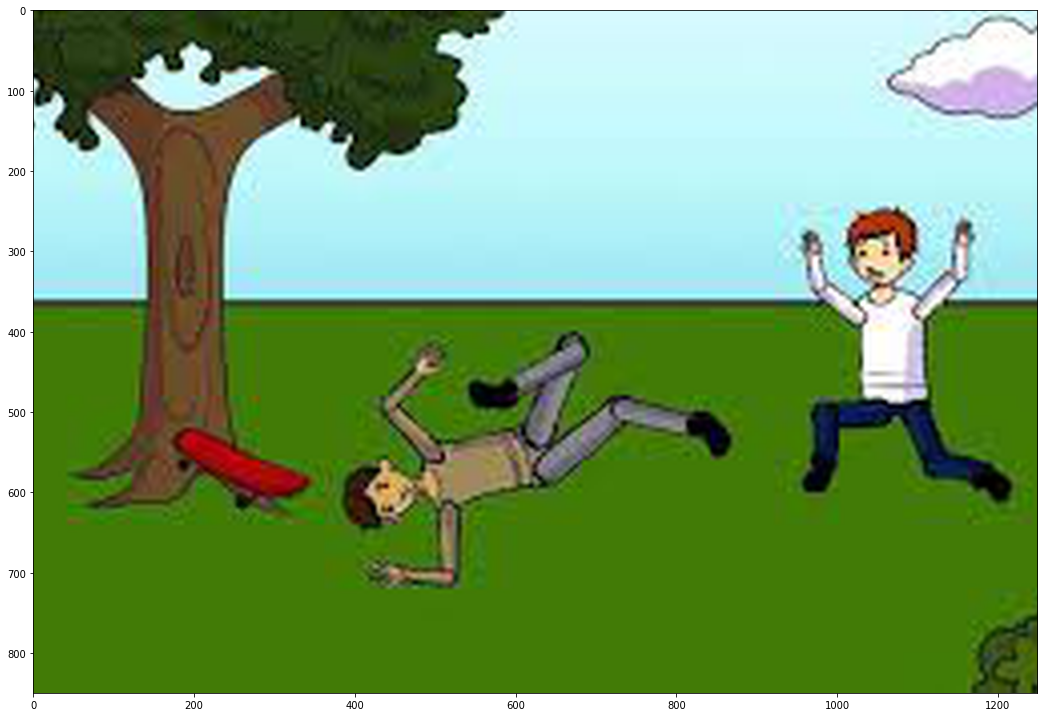

In [ ]:
img_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTg6bu2zL6SJsjFxz2-fSV7LkWSX9ZCY4uvFw&usqp=CAU"#@param
web_img = get_and_reshape_img(img_url, 1250, 850, True)

Found 100 objects.
Inference time:  58.07274627685547
{'Person': 0.8391769, 'Tree': 0.68483543, 'Human face': 0.56108195, 'Boy': 0.4416501, 'Sports equipment': 0.43295506, 'Clothing': 0.36743718, 'Human head': 0.18812183, 'Giraffe': 0.13131951, 'Man': 0.12726806, 'Human hair': 0.12121218, 'Footwear': 0.11982194, 'Human arm': 0.08478153, 'Baseball glove': 0.07002543, 'Human body': 0.059811626, 'Poster': 0.048947472, 'Microphone': 0.0479573, 'Woman': 0.033592883, 'Deer': 0.031741504, 'Mammal': 0.027209695, 'Horse': 0.026696987, 'Sculpture': 0.026446827, 'Human hand': 0.023463577, 'Fashion accessory': 0.0190269, 'Animal': 0.017912678, 'Plant': 0.016520929, 'Helmet': 0.014644591, 'Glove': 0.011160867, 'Dog': 0.010314495, 'Human leg': 0.009296349, 'Girl': 0.006902032, 'Sports uniform': 0.0067898068, 'Flower': 0.0065442068, 'Dinosaur': 0.0063381908, 'Swimwear': 0.006293483, 'Bat': 0.0059781056, 'Maple': 0.0059393346}
Average prediction accuracy for 36 class is:0.12886713665082222



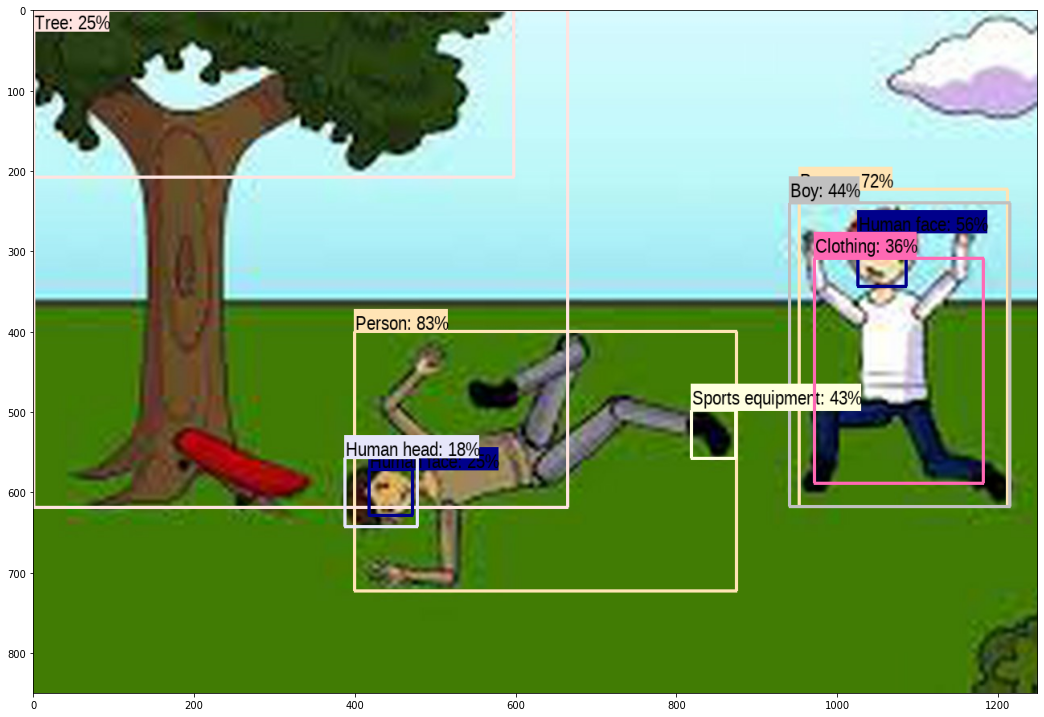

In [ ]:
run_model(model,web_img)